In [1]:
import pandas as pd

In [2]:
titanic = pd.read_csv("data/titanic.csv")

In [3]:
air_quality = pd.read_csv("data/air_quality_long.csv")

In [4]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
air_quality.head()

,city,country,date.utc,location,parameter,value,unit
0,Antwerpen,BE,2019-06-18 06:00:00+00:00,BETR801,pm25,18.0,µg/m³
1,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,pm25,6.5,µg/m³
2,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,pm25,18.5,µg/m³
3,Antwerpen,BE,2019-06-17 06:00:00+00:00,BETR801,pm25,16.0,µg/m³
4,Antwerpen,BE,2019-06-17 05:00:00+00:00,BETR801,pm25,7.5,µg/m³


In [6]:
#reshaping the layout of tables
#sort the table rows 

In [7]:
#With DataFrame.sort_values(), 
#the rows in the table are sorted according to the defined column(s). The index will follow the row order.



In [8]:
titanic.sort_values(by="Age").head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S


In [9]:
#sort the Titanic data according to the cabin class and age in descending order

In [10]:
titanic.sort_values(by=['Pclass', 'Age'], ascending=False).head

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
851          852         0       3   
116          117         0       3   
280          281         0       3   
483          484         1       3   
326          327         0       3   
..           ...       ...     ...   
766          767         0       1   
793          794         0       1   
815          816         0       1   
839          840         1       1   
849          850         1       1   

                                             Name     Sex   Age  SibSp  Parch  \
851                           Svensson, Mr. Johan    male  74.0      0      0   
116                          Connors, Mr. Patrick    male  70.5      0      0   
280                              Duane, Mr. Frank    male  65.0      0      0   
483                        Turkula, Mrs. (Hedwig)  female  63.0      0      0   
326                     Nysveen, Mr. Johan Hansen    male  61.0      0      0   
..                         

In [11]:
#LONG TO WIDE FORMAT

In [12]:
# filter for no2 data only

In [13]:
no2 = air_quality[air_quality["parameter"]== "no2"]

In [14]:
# use 2 measurements (head) for each location (groupby)

In [15]:
no2_subset = no2.sort_index().groupby(["location"]).head(2)

In [16]:
no2_subset

,city,country,date.utc,location,parameter,value,unit
1825,Paris,FR,2019-06-21 00:00:00+00:00,FR04014,no2,20.0,µg/m³
1826,Paris,FR,2019-06-20 23:00:00+00:00,FR04014,no2,21.8,µg/m³
3501,Antwerpen,BE,2019-06-17 08:00:00+00:00,BETR801,no2,41.0,µg/m³
3502,Antwerpen,BE,2019-06-17 07:00:00+00:00,BETR801,no2,45.0,µg/m³
3664,London,GB,2019-06-17 11:00:00+00:00,London Westminster,no2,11.0,µg/m³
3665,London,GB,2019-06-17 10:00:00+00:00,London Westminster,no2,11.0,µg/m³


In [17]:
#I want the values for the three stations as separate columns next to each other

In [21]:
no2_subset.pivot(columns="location", values="value")


location,BETR801,FR04014,London Westminster
1825,NaN,20.0,NaN
1826,NaN,21.8,NaN
3501,41.0,NaN,NaN
3502,45.0,NaN,NaN
3664,NaN,NaN,11.0
3665,NaN,NaN,11.0


In [22]:
#The pivot() function is purely reshaping of the data: a single value for each index/column combination is required

<Axes: >

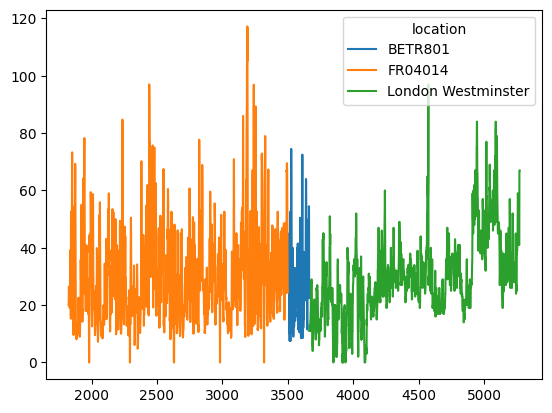

In [23]:
no2.pivot(columns = "location",values = "value").plot()

In [24]:
#pivot table

In [26]:
#I want the mean concentrations for 𝑁⁢𝑂2 and 𝑃⁢𝑀2.5 in each of the stations in table form.



In [27]:
#if index for stated the existing index(row labels) are used
air_quality.pivot_table(
    values="value", index="location", columns="parameter", aggfunc="mean"
)

parameter,no2,pm25
location,,
BETR801,26.950920,23.169492
FR04014,29.374284,NaN
London Westminster,29.740050,13.443568


In [ ]:
#In the case of pivot(), the data is only rearranged. When multiple values need to be aggregated (in this specific case, the values on different time steps), pivot_table() can be used,
#providing an aggregation function (e.g. mean) on how to combine these values.

In [28]:
# pivot_table() is indeed directly linked to groupby(). The same result can be derived by grouping on both parameter and location

In [32]:
air_quality.groupby(["parameter","location"])[["value"]].mean()

value
parameter location                     
no2       BETR801             26.950920
          FR04014             29.374284
          London Westminster  29.740050
pm25      BETR801             23.169492
          London Westminster  13.443568